In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## Step 1: Data Loading

In [3]:
df = pd.read_csv('ab_data.csv')

In [4]:
df.head(10)

,user_id,timestamp,group,landing_page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1
5,936923,20:49.1,control,old_page,0
6,679687,26:46.9,treatment,new_page,1
7,719014,48:29.5,control,old_page,0
8,817355,58:09.0,treatment,new_page,1
9,839785,11:06.6,treatment,new_page,1


**Problem:** An e-commerce site has designed a new landing page. 294K users were randomly divided into two groups — the control group was shown the old page, and the treatment group was shown the new page. The question is simple: does the new page change the conversion rate?

**Hypothesis;**
H₀ (Null): p₁ = p₂ — There is no difference in conversion rate between the new and old pages.
H₁ (Alternative): p₁ ≠ p₂ — There is a significant difference in the conversion rate between the new and old pages.

Test parameters
Significance (alpha); 0.05
Power(1-beta);0.80
Test direction; two-tailed test (I use a two-tailed test since we want to detect any difference, whether positive or negative.)

In [5]:
# Grup vs sayfa eşleşmesi — mismatch'leri görelim
pd.crosstab(df['group'], df['landing_page'])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145313,1965


## Step 2: Data Cleaning

Two issues were identified in the raw data:
1. **Mismatch** — Some users were shown the wrong page (e.g., control group seeing new_page). These are experiment errors that contaminate the treatment effect.
2. **Duplicate** — Some users appear multiple times. A/B tests assume each observation is independent.

### 2.1 Mismatch Detection

In [6]:
# Yanlış eşleşen satırları işaretle
mismatch_mask = (
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
)

print(f"Mismatch sayısı: {mismatch_mask.sum():,} ({mismatch_mask.mean():.2%})")

Mismatch sayısı: 3,893 (1.32%)


### 2.2 Removing Mismatched Records

3,893 mismatched records will be dropped. Why drop instead of reassign? Because these users' experience is contaminated — a control user who saw the new page doesn't cleanly represent either group.

In [7]:
# Sadece doğru eşleşenleri tut
df_clean = df[~mismatch_mask].copy()

print(f"Öncesi: {len(df):,} → Sonrası: {len(df_clean):,}")
print(f"Silinen: {mismatch_mask.sum():,}")

Öncesi: 294,480 → Sonrası: 290,587
Silinen: 3,893


In [8]:
pd.crosstab(df_clean['group'], df_clean['landing_page'])

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145313,0


### 2.3 Duplicate Detection and Removal

Duplicate users violate the independence assumption. We keep the first record and drop subsequent ones.

In [9]:
# Aynı user_id birden fazla var mı?
n_dup = df_clean['user_id'].duplicated().sum()
print(f"Duplicate user_id: {n_dup}")

# Detay
df_clean['user_id'].value_counts().head(10)

Duplicate user_id: 2


user_id
773192    2
759899    2
851104    1
804228    1
661590    1
853541    1
864975    1
936923    1
679687    1
719014    1
Name: count, dtype: int64

In [10]:
df_clean = df_clean.drop_duplicates(subset='user_id',keep='first')

print(f"Temiz veri: {len(df_clean):,} satır")
print(f"Benzersiz kullanıcı: {df_clean['user_id'].nunique():,}")

Temiz veri: 290,585 satır
Benzersiz kullanıcı: 290,585


### 2.4 Clean Data Validation

Post-cleaning checks: zero mismatches, zero duplicates, balanced group sizes.

In [11]:
# Her şey temiz mi?
print("=== FINAL KONTROL ===")
print(f"Mismatch: {((df_clean['group']=='control') & (df_clean['landing_page']=='new_page')).sum()}")
print(f"Duplicate: {df_clean['user_id'].duplicated().sum()}")
print(f"\nGrup dağılımı:")
print(df_clean['group'].value_counts())
print(f"\nDönüşüm oranları:")
print(df_clean.groupby('group')['converted'].agg(['count', 'sum', 'mean']).round(4))

=== FINAL KONTROL ===
Mismatch: 0
Duplicate: 0

Grup dağılımı:
group
treatment    145311
control      145274
Name: count, dtype: int64

Dönüşüm oranları:
            count    sum    mean
group                           
control    145274  17489  0.1204
treatment  145311  17264  0.1188


## Step 3: Exploratory Data Analysis (EDA)

Now that we have clean data (290,585 users), let's explore the conversion rates and group distributions before running any statistical tests.

In [12]:
print(f"Total users: {len(df_clean):,}")
print(f"Total conversions: {df_clean['converted'].sum():,}")
print(f"Overall conversion rate: {df_clean['converted'].mean():.2%}")

Total users: 290,585
Total conversions: 34,753
Overall conversion rate: 11.96%


In [13]:
df_clean.groupby('group')['converted'].agg(['count', 'sum', 'mean']).round(4)

,count,sum,mean
group,,,
control,145274,17489,0.1204
treatment,145311,17264,0.1188


In [19]:
p_ctrl = df_clean[df_clean['group'] == 'control']['converted'].mean()
p_treat = df_clean[df_clean['group'] == 'treatment']['converted'].mean()

diff = p_treat - p_ctrl
relative_diff = diff / p_ctrl

print(f"Control:   {p_ctrl:.4f} ({p_ctrl:.2%})")
print(f"Treatment: {p_treat:.4f} ({p_treat:.2%})")
print(f"Absolute diff: {diff:.4f} ({diff:.2%})")
print(f"Relative diff: {relative_diff:.2%}")

Control:   0.1204 (12.04%)
Treatment: 0.1188 (11.88%)
Absolute diff: -0.0016 (-0.16%)
Relative diff: -1.31%


The new page has a slightly **lower** conversion rate than the old page. The negative sign indicates that treatment underperforms control. Whether this difference is statistically significant or just random noise will be tested in the upcoming steps.

> **Note:** "pp" stands for percentage points — the raw difference between two percentages. Relative difference divides the absolute difference by the baseline (control) rate.

In [15]:
pd.crosstab(df_clean['group'], df_clean['converted'], margins=True)

converted,0,1,All
group,,,
control,127785,17489,145274
treatment,128047,17264,145311
All,255832,34753,290585


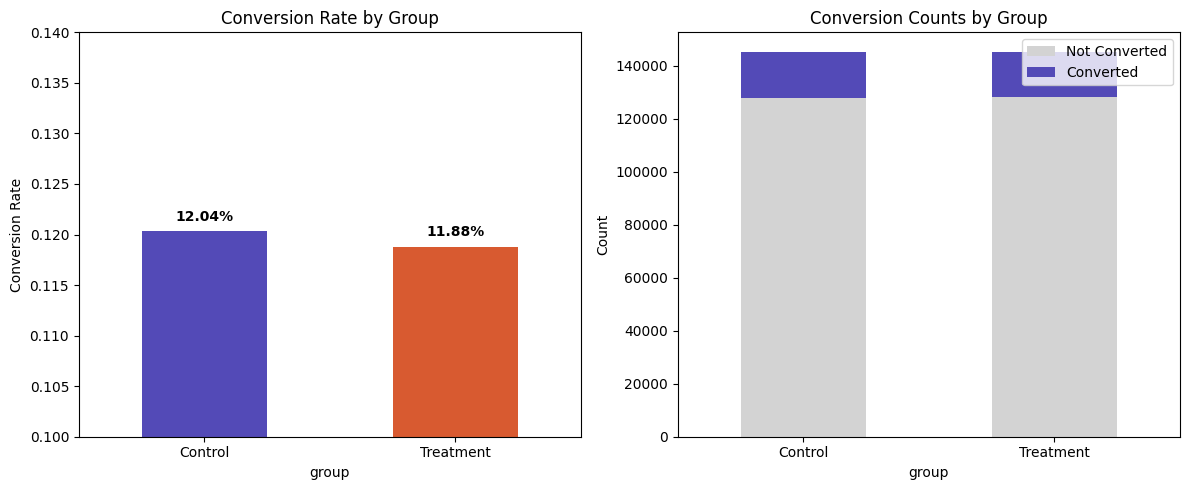

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart — conversion rates
rates = df_clean.groupby('group')['converted'].mean()
colors = ['#534AB7', '#D85A30']
rates.plot(kind='bar', ax=axes[0], color=colors, edgecolor='none')
axes[0].set_title('Conversion Rate by Group')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_ylim(0.10, 0.14)
axes[0].set_xticklabels(['Control', 'Treatment'], rotation=0)

for i, v in enumerate(rates):
    axes[0].text(i, v + 0.001, f'{v:.2%}', ha='center', fontweight='bold')

# Stacked bar — counts
ct = pd.crosstab(df_clean['group'], df_clean['converted'])
ct.columns = ['Not Converted', 'Converted']
ct.plot(kind='bar', stacked=True, ax=axes[1], color=['lightgray', '#534AB7'], edgecolor='none')
axes[1].set_title('Conversion Counts by Group')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Control', 'Treatment'], rotation=0)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [17]:
n_ctrl = len(df_clean[df_clean['group'] == 'control'])
n_treat = len(df_clean[df_clean['group'] == 'treatment'])

print(f"Control:   {n_ctrl:,} ({n_ctrl/len(df_clean):.2%})")
print(f"Treatment: {n_treat:,} ({n_treat/len(df_clean):.2%})")
print(f"Ratio: {n_ctrl/n_treat:.4f} (1.0 = perfect balance)")

Control:   145,274 (49.99%)
Treatment: 145,311 (50.01%)
Ratio: 0.9997 (1.0 = perfect balance)


### EDA Summary

- **Control** conversion rate: 12.04% — **Treatment** conversion rate: 11.88%
- The new page performs **0.16pp worse** than the old page (relative: -1.31%)
- Groups are nearly perfectly balanced (ratio 0.9997)
- The difference looks small — but is it statistically significant or just random noise?

→ Next: Power analysis to check if our sample size can detect this difference.

## Step 4: Sample Size & Power Analysis

Before testing, we need to verify: is our sample large enough to detect a meaningful difference? Power analysis answers this by connecting four parameters: significance level (α), power (1-β), minimum detectable effect (MDE), and required sample size.

In [21]:
from scipy.stats import norm
import numpy as np

def calculate_sample_size(p1, p2, alpha=0.05, power=0.80):
    """
    Required sample size per group for two-proportion z-test.
    
    Formula: n = (Z_{α/2} + Z_β)² × (p1(1-p1) + p2(1-p2)) / (p2 - p1)²
    """
    z_alpha = norm.ppf(1 - alpha / 2)   # 1.96 for α=0.05
    z_beta = norm.ppf(power)             # 0.84 for power=0.80
    
    var1 = p1 * (1 - p1)
    var2 = p2 * (1 - p2)
    
    n = ((z_alpha + z_beta) ** 2 * (var1 + var2)) / (p2 - p1) ** 2
    return int(np.ceil(n))

# Our observed values
baseline = p_ctrl   # 0.1204
observed_diff = abs(p_treat - p_ctrl)  # 0.0016

n_required = calculate_sample_size(baseline, baseline + observed_diff)

print(f"Baseline conversion rate: {baseline:.4f}")
print(f"Observed difference: {observed_diff:.4f}")
print(f"Required sample size per group: {n_required:,}")
print(f"Our actual sample per group: ~{len(df_clean)//2:,}")
print(f"\nVerdict: {'Sufficient' if len(df_clean)//2 > n_required else 'Not enough'}")

Baseline conversion rate: 0.1204
Observed difference: 0.0016
Required sample size per group: 670,437
Our actual sample per group: ~145,292

Verdict: Not enough


In [22]:
print("MDE (pp)  | Required n/group | Our n/group | Sufficient?")
print("-" * 60)

our_n = len(df_clean) // 2

for mde in [0.001, 0.005, 0.01, 0.02, 0.05]:
    n = calculate_sample_size(baseline, baseline + mde)
    enough = "✓" if our_n > n else "✗"
    print(f"  {mde:<8} | {n:>16,} | {our_n:>11,} | {enough}")

MDE (pp)  | Required n/group | Our n/group | Sufficient?
------------------------------------------------------------
  0.001    |        1,668,242 |     145,292 | ✗
  0.005    |           67,676 |     145,292 | ✓
  0.01     |           17,211 |     145,292 | ✓
  0.02     |            4,446 |     145,292 | ✓
  0.05     |              777 |     145,292 | ✓


In [23]:
from scipy.stats import norm
import numpy as np

def calculate_power(p1, p2, n, alpha=0.05):
    """
    Actual power of our test given the sample size we have.
    """
    z_alpha = norm.ppf(1 - alpha / 2)
    
    se = np.sqrt(p1 * (1 - p1) / n + p2 * (1 - p2) / n)
    z_stat = abs(p2 - p1) / se
    
    power = 1 - norm.cdf(z_alpha - z_stat)
    return power

n_per_group = len(df_clean) // 2
actual_power = calculate_power(p_ctrl, p_treat, n_per_group)

print(f"Sample per group: {n_per_group:,}")
print(f"Observed difference: {abs(p_treat - p_ctrl):.4f}")
print(f"Actual power: {actual_power:.4f} ({actual_power:.1%})")
print(f"\nInterpretation: We have a {actual_power:.1%} chance of detecting")
print(f"a {abs(p_treat - p_ctrl):.4f} difference if it truly exists.")

Sample per group: 145,292
Observed difference: 0.0016
Actual power: 0.2584 (25.8%)

Interpretation: We have a 25.8% chance of detecting
a 0.0016 difference if it truly exists.


### Power Analysis Result

Our test has only **25.8% power** to detect the observed 0.16pp difference — well below the 80% threshold. This means:

- Even if the difference is real, we'd miss it ~74% of the time.
- However, our sample **can reliably detect differences ≥ 0.5pp** (see MDE table above).
- Since no meaningful difference (≥ 0.5pp) was found despite sufficient power for that range, the new page likely has **no practically significant effect** on conversion.

**Key takeaway:** A "not significant" result here doesn't mean our test failed — it means there is no difference large enough to matter for business decisions.

## Step 5: Frequentist Hypothesis Testing

Now we run the actual statistical tests. We'll use two methods:
1. **Two-proportion Z-test** — directly compares two conversion rates
2. **Chi-square test** — tests independence between group and conversion

Both should give consistent results.

In [27]:
from scipy.stats import norm
import numpy as np
alpha = 0.05
# Sample sizes
n_ctrl = len(df_clean[df_clean['group'] == 'control'])
n_treat = len(df_clean[df_clean['group'] == 'treatment'])

# Conversions
x_ctrl = df_clean[df_clean['group'] == 'control']['converted'].sum()
x_treat = df_clean[df_clean['group'] == 'treatment']['converted'].sum()

# Pooled proportion under H0
p_pool = (x_ctrl + x_treat) / (n_ctrl + n_treat)

# Standard error under H0
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_ctrl + 1/n_treat))

# Z statistic
z_stat = (p_treat - p_ctrl) / se

# P-value (two-tailed)
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print("=== Two-Proportion Z-Test ===")
print(f"Pooled proportion: {p_pool:.4f}")
print(f"Standard Error:    {se:.4f}")
print(f"Z statistic:       {z_stat:.4f}")
print(f"P-value:           {p_value:.4f}")
print(f"\nα = {alpha}")
print(f"Result: {'Reject H₀' if p_value < alpha else 'Fail to reject H₀'}")

=== Two-Proportion Z-Test ===
Pooled proportion: 0.1196
Standard Error:    0.0012
Z statistic:       -1.3116
P-value:           0.1897

α = 0.05
Result: Fail to reject H₀


In [28]:
print(f"p-value ({p_value:.4f}) {'<' if p_value < alpha else '>'} α ({alpha})")
if p_value >= alpha:
    print("→ Not enough evidence to say the new page is different from the old page.")
else:
    print("→ The difference is statistically significant.")

p-value (0.1897) > α (0.05)
→ Not enough evidence to say the new page is different from the old page.


In [29]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df_clean['group'], df_clean['converted'])

chi2, p_value_chi2, dof, expected = chi2_contingency(ct)

print("=== Chi-Square Test ===")
print(f"Chi² statistic:    {chi2:.4f}")
print(f"P-value:           {p_value_chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"\nResult: {'Reject H₀' if p_value_chi2 < alpha else 'Fail to reject H₀'}")

=== Chi-Square Test ===
Chi² statistic:    1.7054
P-value:           0.1916
Degrees of freedom: 1

Result: Fail to reject H₀


In [30]:
# 95% confidence interval for the difference
se_diff = np.sqrt(p_ctrl * (1 - p_ctrl) / n_ctrl + p_treat * (1 - p_treat) / n_treat)
diff = p_treat - p_ctrl
ci_lower = diff - 1.96 * se_diff
ci_upper = diff + 1.96 * se_diff

print("=== 95% Confidence Interval ===")
print(f"Difference: {diff:.4f}")
print(f"CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\nCI contains zero: {ci_lower < 0 < ci_upper}")
print("→ If CI contains zero, the difference is not significant.")

=== 95% Confidence Interval ===
Difference: -0.0016
CI: [-0.0039, 0.0008]

CI contains zero: True
→ If CI contains zero, the difference is not significant.


In [31]:
# Cohen's h — effect size for two proportions
h = 2 * (np.arcsin(np.sqrt(p_treat)) - np.arcsin(np.sqrt(p_ctrl)))

print("=== Effect Size ===")
print(f"Cohen's h: {h:.4f}")
if abs(h) < 0.2:
    label = "Small (negligible)"
elif abs(h) < 0.5:
    label = "Medium"
else:
    label = "Large"
print(f"Interpretation: {label}")

=== Effect Size ===
Cohen's h: -0.0049
Interpretation: Small (negligible)


### Step 5 Summary

| Test | Statistic | P-value | Result |
|------|-----------|---------|--------|
| Z-test | z = -1.31 | 0.1897 | Fail to reject H₀ |
| Chi-square | χ² = 1.71 | 0.1916 | Fail to reject H₀ |

- **95% CI:** [-0.39pp, +0.08pp] — contains zero, difference is not significant
- **Cohen's h:** -0.005 — negligible effect size
- **Power context:** Our test could detect differences ≥ 0.5pp but found none, reinforcing that any real difference is too small to matter

Both tests agree: **there is no statistically significant difference between the old and new page.**

→ Next: Bayesian A/B test to quantify the probability that one page is better than the other.

## Step 6: Bayesian A/B Test

The frequentist approach says "reject or not." Bayesian approach answers a more intuitive question: **"What is the probability that the old page is actually better than the new page?"**

We use the Beta-Binomial model:
- **Prior:** Beta(1, 1) — uniform, no prior assumption
- **Posterior:** Beta(1 + conversions, 1 + non-conversions)

Then we simulate 100K samples from each posterior and directly compare them.

In [32]:
from scipy.stats import beta

# Prior: Beta(1,1) — non-informative
a_prior, b_prior = 1, 1

# Posterior parameters
a_ctrl = a_prior + x_ctrl
b_ctrl = b_prior + (n_ctrl - x_ctrl)

a_treat = a_prior + x_treat
b_treat = b_prior + (n_treat - x_treat)

print("=== Posterior Distributions ===")
print(f"Control:   Beta({a_ctrl}, {b_ctrl})  →  mean = {a_ctrl/(a_ctrl+b_ctrl):.4f}")
print(f"Treatment: Beta({a_treat}, {b_treat})  →  mean = {a_treat/(a_treat+b_treat):.4f}")

=== Posterior Distributions ===
Control:   Beta(17490, 127786)  →  mean = 0.1204
Treatment: Beta(17265, 128048)  →  mean = 0.1188


In [33]:
np.random.seed(42)
n_sim = 100_000

samples_ctrl = beta.rvs(a_ctrl, b_ctrl, size=n_sim)
samples_treat = beta.rvs(a_treat, b_treat, size=n_sim)

prob_ctrl_better = (samples_ctrl > samples_treat).mean()
prob_treat_better = (samples_treat > samples_ctrl).mean()

print("=== Monte Carlo Simulation (100K samples) ===")
print(f"P(Control > Treatment) = {prob_ctrl_better:.4f} ({prob_ctrl_better:.1%})")
print(f"P(Treatment > Control) = {prob_treat_better:.4f} ({prob_treat_better:.1%})")

=== Monte Carlo Simulation (100K samples) ===
P(Control > Treatment) = 0.9065 (90.6%)
P(Treatment > Control) = 0.0935 (9.4%)


In [34]:
# Expected loss: if we pick the wrong page, how much do we lose?
loss_if_treat = np.maximum(samples_ctrl - samples_treat, 0).mean()
loss_if_ctrl = np.maximum(samples_treat - samples_ctrl, 0).mean()

# Relative lift distribution
lift = (samples_treat - samples_ctrl) / samples_ctrl

print("=== Expected Loss ===")
print(f"If we choose treatment (new page): {loss_if_treat:.5f}")
print(f"If we choose control (old page):   {loss_if_ctrl:.5f}")
print(f"\n=== Relative Lift ===")
print(f"Mean lift: {lift.mean():.2%}")
print(f"95% CI: [{np.percentile(lift, 2.5):.2%}, {np.percentile(lift, 97.5):.2%}]")

=== Expected Loss ===
If we choose treatment (new page): 0.00164
If we choose control (old page):   0.00005

=== Relative Lift ===
Mean lift: -1.31%
95% CI: [-3.25%, 0.66%]


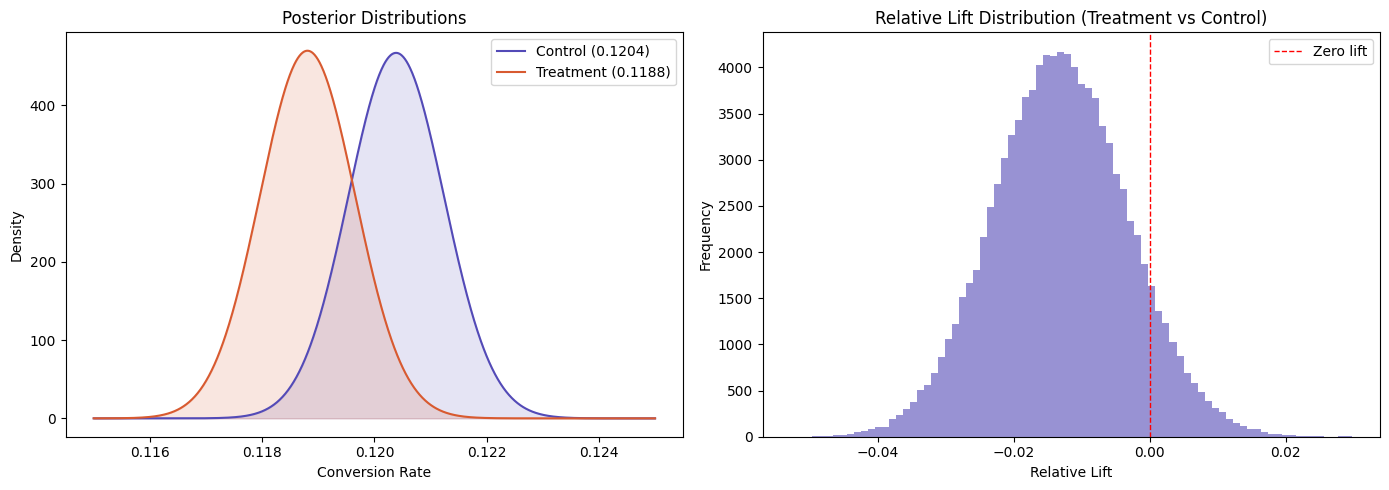

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posterior distributions
x = np.linspace(0.115, 0.125, 1000)
axes[0].plot(x, beta.pdf(x, a_ctrl, b_ctrl), color='#534AB7', label=f'Control ({a_ctrl/(a_ctrl+b_ctrl):.4f})')
axes[0].plot(x, beta.pdf(x, a_treat, b_treat), color='#D85A30', label=f'Treatment ({a_treat/(a_treat+b_treat):.4f})')
axes[0].fill_between(x, beta.pdf(x, a_ctrl, b_ctrl), alpha=0.15, color='#534AB7')
axes[0].fill_between(x, beta.pdf(x, a_treat, b_treat), alpha=0.15, color='#D85A30')
axes[0].set_title('Posterior Distributions')
axes[0].set_xlabel('Conversion Rate')
axes[0].set_ylabel('Density')
axes[0].legend()

# Lift distribution
axes[1].hist(lift, bins=80, color='#534AB7', alpha=0.6, edgecolor='none')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1, label='Zero lift')
axes[1].set_title('Relative Lift Distribution (Treatment vs Control)')
axes[1].set_xlabel('Relative Lift')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

### Step 6 Summary

Bayesian analysis provides direct probability statements:

| Metric | Value |
|--------|-------|
| P(old page is better) | 90.6% |
| P(new page is better) | 9.4% |
| Expected loss (keeping old) | 0.00005 |
| Expected loss (switching to new) | 0.00164 |
| Mean relative lift | -1.31% |
| Lift 95% CI | [-3.25%, +0.66%] |

The posterior distributions overlap but control is shifted right. The lift distribution is mostly negative, confirming the old page likely performs better.

**Recommendation:** Keep the old page. There is a 90.6% probability it outperforms the new design, and the expected cost of switching is 30x higher than staying.